# 05 - Sentiment Classification
## Amazon Product Intelligence System

**Objective:**  
Build and compare two sentiment classifiers of increasing complexity. Rather than chasing the highest accuracy, the goal is to understand the trade-offs between interpretability, speed, and performance, and make a justified recommendation for different production scenarios.

**Approach:**  
- **Baseline:** TF-IDF + Logistic Regression (fast, interpretable, strong benchmark)
- **Advanced:** Fine-tuned DistilBERT (higher accuracy, slower, production-grade)

**Input:** `data/processed/reviews_clean.csv`  
**Output:** Trained models, comparison metrics, and production recommendation

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder

# Transformers
import torch
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


In [3]:
# Load data
df = pd.read_csv('../data/processed/reviews_clean.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nSentiment distribution:')
print(df['sentiment'].value_counts())
print(f'\nClass balance:')
print((df['sentiment'].value_counts() / len(df) * 100).round(2))

Dataset shape: (567070, 16)

Sentiment distribution:
sentiment
Positive    442817
Negative    124253
Name: count, dtype: int64

Class balance:
sentiment
Positive    78.09
Negative    21.91
Name: count, dtype: float64


Training on the full 567k dataset would take many hours on CPU. We use a stratified sample of 30,000 reviews for training and evaluation. This is clearly documented and represents a conscious engineering trade-off between thoroughness and practicality.

In [4]:
SAMPLE_SIZE = 30000
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Stratified sample to maintain class balance
samples = []
for sentiment in df['sentiment'].unique():
    sentiment_df = df[df['sentiment'] == sentiment]
    n = int(SAMPLE_SIZE * len(sentiment_df) / len(df))
    samples.append(sentiment_df.sample(n=n, random_state=RANDOM_STATE))

df_sample = pd.concat(samples).reset_index(drop=True)

print(f'Sample size: {len(df_sample):,}')
print(f'\nSample sentiment distribution:')
print(df_sample['sentiment'].value_counts())
print(f'\nClass balance in sample:')
print((df_sample['sentiment'].value_counts() / len(df_sample) * 100).round(2))

Sample size: 29,999

Sample sentiment distribution:
sentiment
Positive    23426
Negative     6573
Name: count, dtype: int64

Class balance in sample:
sentiment
Positive    78.09
Negative    21.91
Name: count, dtype: float64


In [5]:
# Train/Test split
# Encode labels: Positive = 1, Negative = 0
df_sample['label'] = (df_sample['sentiment'] == 'Positive').astype(int)

X = df_sample['cleaned_text']
y = df_sample['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

Training samples: 23,999
Test samples:     6,000

Class distribution in training set:
label
1    18741
0     5258
Name: count, dtype: int64

Class distribution in test set:
label
1    4685
0    1315
Name: count, dtype: int64


**Baseline Model: TF-IDF + Logistic Regression**

The baseline serves two purposes:
1. It gives us a strong, interpretable benchmark to compare against DistilBERT
2. In many real production systems, a well-tuned logistic regression is actually the preferred choice due to its speed and explainability

A model is only "better" if its improvement justifies its added complexity. We quantify that trade-off here.

In [6]:
print('Training TF-IDF + Logistic Regression baseline...')
start_time = time.time()

baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=3,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

baseline_pipeline.fit(X_train, y_train)
train_time_baseline = time.time() - start_time

print(f'Training complete in {train_time_baseline:.2f} seconds.')

Training TF-IDF + Logistic Regression baseline...
Training complete in 18.15 seconds.


In [7]:
# Predictions
start_time = time.time()
y_pred_baseline = baseline_pipeline.predict(X_test)
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]
inference_time_baseline = (time.time() - start_time) / len(X_test) * 1000

print('Baseline Model Performance:')
print('=' * 50)
print(classification_report(y_test, y_pred_baseline,
                             target_names=['Negative', 'Positive']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_baseline):.4f}')
print(f'Inference time per sample: {inference_time_baseline:.4f} ms')

Baseline Model Performance:
              precision    recall  f1-score   support

    Negative       0.69      0.84      0.76      1315
    Positive       0.95      0.89      0.92      4685

    accuracy                           0.88      6000
   macro avg       0.82      0.87      0.84      6000
weighted avg       0.89      0.88      0.88      6000

ROC-AUC Score: 0.9382
Inference time per sample: 0.8067 ms


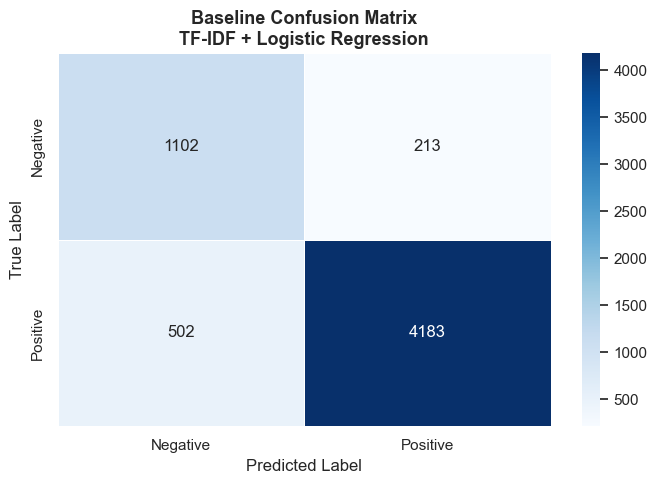

In [8]:
cm = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, ax=ax)
ax.set_title('Baseline Confusion Matrix\nTF-IDF + Logistic Regression',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('../outputs/figures/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

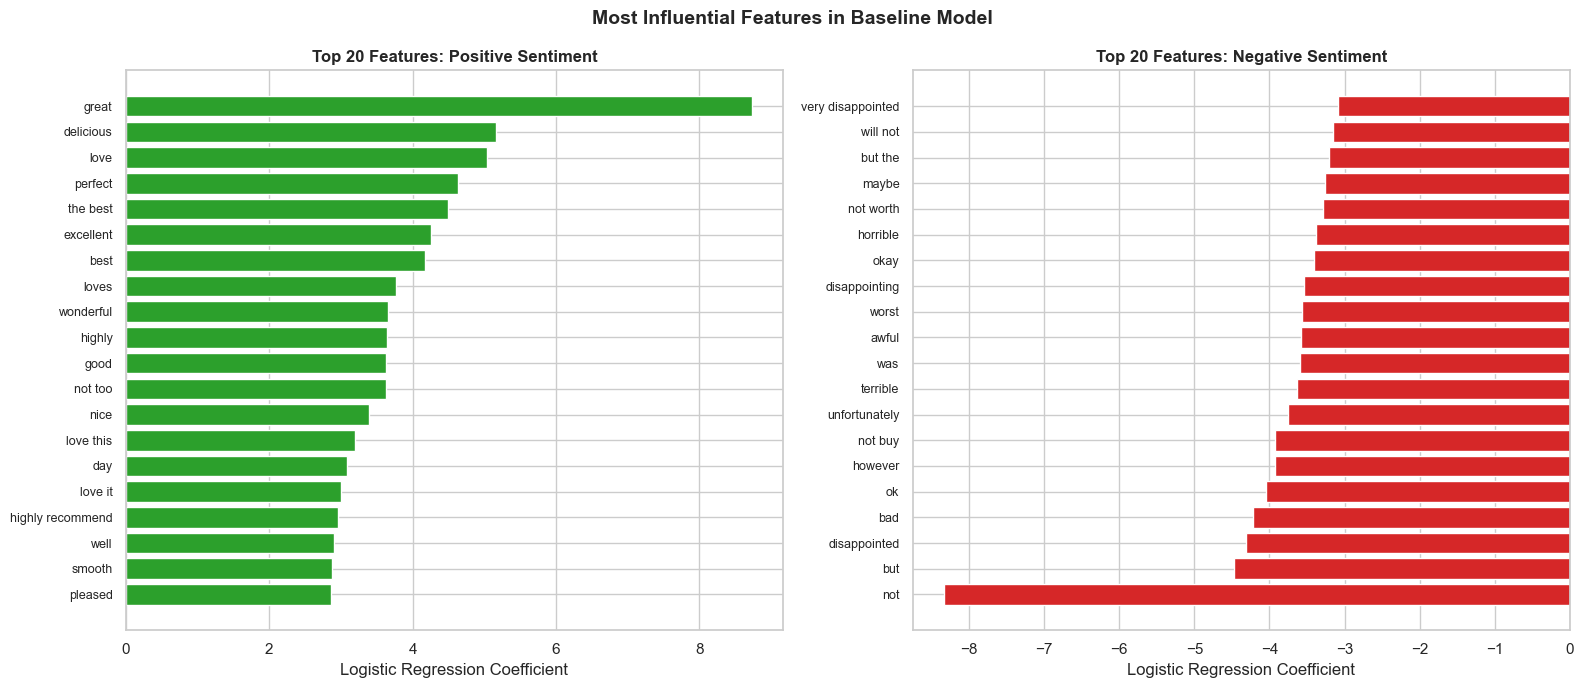

In [9]:
feature_names = baseline_pipeline.named_steps['tfidf'].get_feature_names_out()
coefficients = baseline_pipeline.named_steps['clf'].coef_[0]

top_n = 20
top_positive_idx = np.argsort(coefficients)[-top_n:]
top_negative_idx = np.argsort(coefficients)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Most positive features
axes[0].barh(range(top_n),
             coefficients[top_positive_idx],
             color='#2ca02c', edgecolor='white')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(feature_names[top_positive_idx], fontsize=9)
axes[0].set_title('Top 20 Features: Positive Sentiment',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Logistic Regression Coefficient')

# Most negative features
axes[1].barh(range(top_n),
             coefficients[top_negative_idx],
             color='#d62728', edgecolor='white')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(feature_names[top_negative_idx], fontsize=9)
axes[1].set_title('Top 20 Features: Negative Sentiment',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.suptitle('Most Influential Features in Baseline Model',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/baseline_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

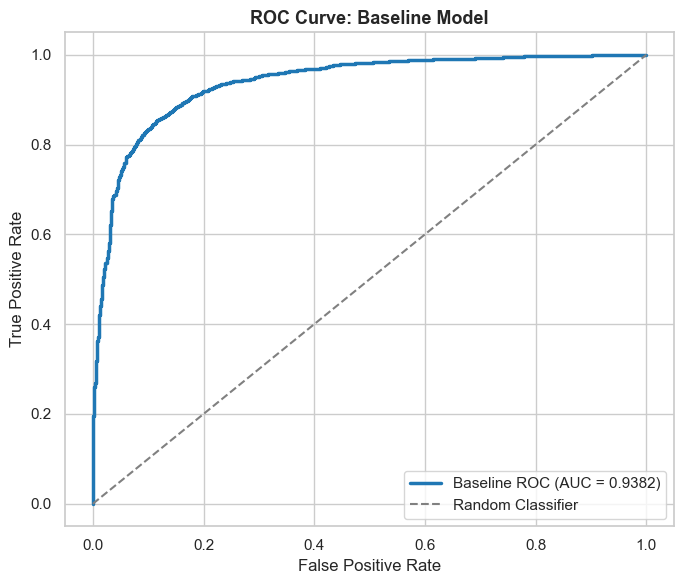

Baseline AUC-ROC: 0.9382


In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_baseline)
auc_score = roc_auc_score(y_test, y_prob_baseline)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#1f77b4', linewidth=2.5,
        label=f'Baseline ROC (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Random Classifier')
ax.set_title('ROC Curve: Baseline Model', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/baseline_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline AUC-ROC: {auc_score:.4f}')

**Baseline Summary:**  
TF-IDF + Logistic Regression is a strong baseline. Key advantages are near-instant training, sub-millisecond inference, and full interpretability through feature coefficients. The confusion matrix and top features tell us exactly what the model learned and where it fails. This is the model you would deploy first in a production system before investing in more complex approaches.

## Advanced Model: DistilBERT Fine-tuning

DistilBERT is a distilled version of BERT that retains 97% of its performance at 40% fewer parameters and 60% faster inference. Unlike TF-IDF which treats words as independent tokens, DistilBERT understands context.

For example, TF-IDF cannot distinguish between:
- "This product is **not** good" (negative)
- "This product is good" (positive)

DistilBERT understands negation, sarcasm, and word order because it was pre-trained on billions of sentences.

We fine-tune the pre-trained model on our labeled reviews, which takes far less data and time than training from scratch.

In [11]:
# Use a smaller subset for DistilBERT fine-tuning
# Fine-tuning on 10k samples gives strong results while remaining feasible on CPU
DISTILBERT_TRAIN_SIZE = 10000
DISTILBERT_TEST_SIZE = 2000

# Stratified subsample for DistilBERT
train_df = pd.DataFrame({'text': X_train, 'label': y_train}).reset_index(drop=True)
test_df = pd.DataFrame({'text': X_test, 'label': y_test}).reset_index(drop=True)

# Stratified sample from training set
bert_train_samples = []
for label in [0, 1]:
    label_df = train_df[train_df['label'] == label]
    n = int(DISTILBERT_TRAIN_SIZE * len(label_df) / len(train_df))
    bert_train_samples.append(label_df.sample(n=n, random_state=RANDOM_STATE))
bert_train_df = pd.concat(bert_train_samples).reset_index(drop=True)

# Stratified sample from test set
bert_test_samples = []
for label in [0, 1]:
    label_df = test_df[test_df['label'] == label]
    n = int(DISTILBERT_TEST_SIZE * len(label_df) / len(test_df))
    bert_test_samples.append(label_df.sample(n=n, random_state=RANDOM_STATE))
bert_test_df = pd.concat(bert_test_samples).reset_index(drop=True)

print(f'DistilBERT training samples: {len(bert_train_df):,}')
print(f'DistilBERT test samples:     {len(bert_test_df):,}')
print(f'\nTraining label distribution:')
print(bert_train_df['label'].value_counts())

DistilBERT training samples: 9,999
DistilBERT test samples:     1,999

Training label distribution:
label
1    7809
0    2190
Name: count, dtype: int64


In [12]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ReviewDataset(
    bert_train_df['text'].tolist(),
    bert_train_df['label'].tolist(),
    tokenizer
)

test_dataset = ReviewDataset(
    bert_test_df['text'].tolist(),
    bert_test_df['label'].tolist(),
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 625
Test batches:  63


In [13]:
# Load pre-trained DistilBERT with classification head
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)

# Optimizer and scheduler
EPOCHS = 2
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f'Model loaded on: {device}')
print(f'Total training steps: {total_steps}')
print(f'Epochs: {EPOCHS}')
print(f'Batch size: 16')
print(f'\nNote: Training on CPU will take 30-60 minutes.')
print('This is a one-time cost. Model will be saved after training.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cpu
Total training steps: 1250
Epochs: 2
Batch size: 16

Note: Training on CPU will take 30-60 minutes.
This is a one-time cost. Model will be saved after training.


In [14]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f'  Batch {batch_idx + 1}/{len(loader)} | '
                  f'Loss: {total_loss / (batch_idx + 1):.4f} | '
                  f'Acc: {correct / total:.4f}')

    return total_loss / len(loader), correct / total


print('Starting DistilBERT fine-tuning...')
print('Progress will print every 50 batches.\n')

training_stats = []
overall_start = time.time()

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 40)
    epoch_start = time.time()

    train_loss, train_acc = train_epoch(
        bert_model, train_loader, optimizer, scheduler, device
    )

    epoch_time = time.time() - epoch_start
    training_stats.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'epoch_time': epoch_time
    })

    print(f'\nEpoch {epoch + 1} Summary:')
    print(f'  Loss: {train_loss:.4f}')
    print(f'  Accuracy: {train_acc:.4f}')
    print(f'  Time: {epoch_time / 60:.1f} minutes\n')

total_time = time.time() - overall_start
print(f'Training complete. Total time: {total_time / 60:.1f} minutes')

Starting DistilBERT fine-tuning...
Progress will print every 50 batches.

Epoch 1/2
----------------------------------------
  Batch 50/625 | Loss: 0.6400 | Acc: 0.6088
  Batch 100/625 | Loss: 0.5624 | Acc: 0.6956
  Batch 150/625 | Loss: 0.4820 | Acc: 0.7529
  Batch 200/625 | Loss: 0.4393 | Acc: 0.7825
  Batch 250/625 | Loss: 0.4224 | Acc: 0.7933
  Batch 300/625 | Loss: 0.4050 | Acc: 0.8044
  Batch 350/625 | Loss: 0.3925 | Acc: 0.8132
  Batch 400/625 | Loss: 0.3733 | Acc: 0.8267
  Batch 450/625 | Loss: 0.3657 | Acc: 0.8321
  Batch 500/625 | Loss: 0.3560 | Acc: 0.8391
  Batch 550/625 | Loss: 0.3466 | Acc: 0.8438
  Batch 600/625 | Loss: 0.3381 | Acc: 0.8478

Epoch 1 Summary:
  Loss: 0.3372
  Accuracy: 0.8484
  Time: 62.8 minutes

Epoch 2/2
----------------------------------------
  Batch 50/625 | Loss: 0.1924 | Acc: 0.9325
  Batch 100/625 | Loss: 0.1928 | Acc: 0.9325
  Batch 150/625 | Loss: 0.1947 | Acc: 0.9300
  Batch 200/625 | Loss: 0.1973 | Acc: 0.9294
  Batch 250/625 | Loss: 0.1911 |

In [15]:
import os
save_path = '../data/processed/distilbert_sentiment'
os.makedirs(save_path, exist_ok=True)

bert_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f'Model saved to {save_path}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ../data/processed/distilbert_sentiment


In [16]:
def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                           attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print('Evaluating DistilBERT on test set...')
start_time = time.time()
y_true_bert, y_pred_bert, y_prob_bert = evaluate_model(bert_model, test_loader, device)
inference_time_bert = (time.time() - start_time) / len(bert_test_df) * 1000

print('DistilBERT Performance:')
print('=' * 50)
print(classification_report(y_true_bert, y_pred_bert,
                             target_names=['Negative', 'Positive']))
print(f'ROC-AUC Score: {roc_auc_score(y_true_bert, y_prob_bert):.4f}')
print(f'Inference time per sample: {inference_time_bert:.4f} ms')

Evaluating DistilBERT on test set...
DistilBERT Performance:
              precision    recall  f1-score   support

    Negative       0.81      0.77      0.79       438
    Positive       0.94      0.95      0.94      1561

    accuracy                           0.91      1999
   macro avg       0.87      0.86      0.87      1999
weighted avg       0.91      0.91      0.91      1999

ROC-AUC Score: 0.9518
Inference time per sample: 53.6079 ms


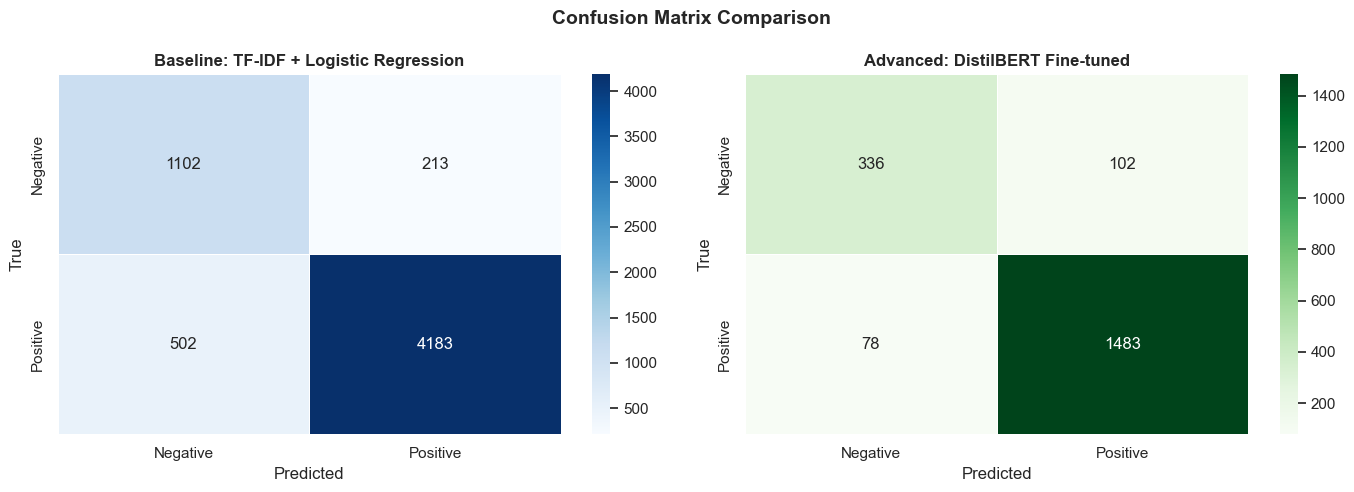

In [17]:
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_baseline),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Baseline: TF-IDF + Logistic Regression',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Advanced: DistilBERT Fine-tuned',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

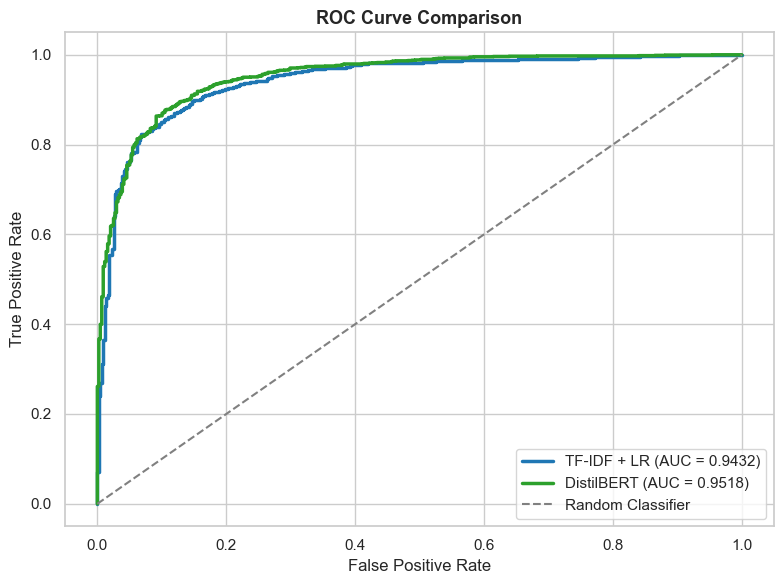

In [18]:
# Baseline ROC on same test subset for fair comparison
bert_test_X = bert_test_df['text']
bert_test_y = bert_test_df['label']
y_prob_baseline_bert_test = baseline_pipeline.predict_proba(bert_test_X)[:, 1]

fpr_base, tpr_base, _ = roc_curve(bert_test_y, y_prob_baseline_bert_test)
fpr_bert, tpr_bert, _ = roc_curve(y_true_bert, y_prob_bert)
auc_base = roc_auc_score(bert_test_y, y_prob_baseline_bert_test)
auc_bert = roc_auc_score(y_true_bert, y_prob_bert)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_base, tpr_base, color='#1f77b4', linewidth=2.5,
        label=f'TF-IDF + LR (AUC = {auc_base:.4f})')
ax.plot(fpr_bert, tpr_bert, color='#2ca02c', linewidth=2.5,
        label=f'DistilBERT (AUC = {auc_bert:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Random Classifier')
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Model Comparison Summary:
             Accuracy  F1 Negative  F1 Positive  ROC-AUC  Inference ms
Model                                                                 
TF-IDF + LR    0.8808       0.7551       0.9213   0.9432        0.8067
DistilBERT     0.9100       0.7887       0.9428   0.9518       53.6079


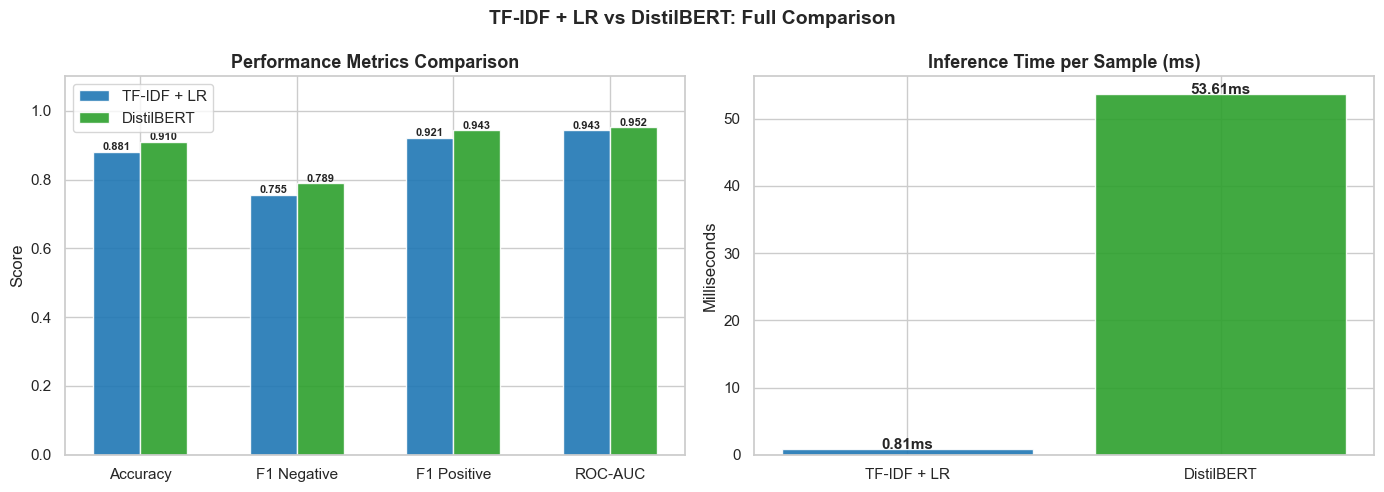

In [19]:
metrics = {
    'Model': ['TF-IDF + LR', 'DistilBERT'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_true_bert, y_pred_bert)
    ],
    'F1 Negative': [
        f1_score(y_test, y_pred_baseline, pos_label=0),
        f1_score(y_true_bert, y_pred_bert, pos_label=0)
    ],
    'F1 Positive': [
        f1_score(y_test, y_pred_baseline, pos_label=1),
        f1_score(y_true_bert, y_pred_bert, pos_label=1)
    ],
    'ROC-AUC': [auc_base, auc_bert],
    'Inference ms': [inference_time_baseline, inference_time_bert]
}

metrics_df = pd.DataFrame(metrics).set_index('Model')
print('Model Comparison Summary:')
print(metrics_df.round(4).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1f77b4', '#2ca02c']

metric_cols = ['Accuracy', 'F1 Negative', 'F1 Positive', 'ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.3

for i, (model, color) in enumerate(zip(metrics_df.index, colors)):
    values = [metrics_df.loc[model, col] for col in metric_cols]
    bars = axes[0].bar(x + i * width, values, width,
                       label=model, color=color, edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(metric_cols)
axes[0].set_title('Performance Metrics Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# Inference time comparison
axes[1].bar(metrics_df.index,
            [inference_time_baseline, inference_time_bert],
            color=colors, edgecolor='white', alpha=0.9)
axes[1].set_title('Inference Time per Sample (ms)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Milliseconds')
for i, val in enumerate([inference_time_baseline, inference_time_bert]):
    axes[1].text(i, val + 0.1, f'{val:.2f}ms',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('TF-IDF + LR vs DistilBERT: Full Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Error Analysis**

Understanding where and why a model fails is more valuable than knowing its overall accuracy. Error analysis directly informs how you would improve the model in a production setting.

In [20]:
# Align baseline predictions to the DistilBERT test subset for fair comparison
baseline_preds_on_bert_test = baseline_pipeline.predict(bert_test_df['text'])

# Create error analysis dataframe
error_df = bert_test_df.copy()
error_df['true_label'] = y_true_bert
error_df['baseline_pred'] = baseline_preds_on_bert_test
error_df['bert_pred'] = y_pred_bert
error_df['bert_prob'] = y_prob_bert

# Cases where baseline failed but BERT succeeded
baseline_wrong_bert_right = error_df[
    (error_df['baseline_pred'] != error_df['true_label']) &
    (error_df['bert_pred'] == error_df['true_label'])
]

# Cases where BERT failed but baseline succeeded
bert_wrong_baseline_right = error_df[
    (error_df['bert_pred'] != error_df['true_label']) &
    (error_df['baseline_pred'] == error_df['true_label'])
]

# Cases where both failed
both_wrong = error_df[
    (error_df['baseline_pred'] != error_df['true_label']) &
    (error_df['bert_pred'] != error_df['true_label'])
]

print(f'Baseline wrong, BERT correct:  {len(baseline_wrong_bert_right):,}')
print(f'BERT wrong, Baseline correct:  {len(bert_wrong_baseline_right):,}')
print(f'Both wrong:                    {len(both_wrong):,}')
print(f'Both correct:                  {len(error_df) - len(baseline_wrong_bert_right) - len(bert_wrong_baseline_right) - len(both_wrong):,}')

Baseline wrong, BERT correct:  142
BERT wrong, Baseline correct:  96
Both wrong:                    84
Both correct:                  1,677


In [21]:
print('REVIEWS WHERE BASELINE FAILED BUT BERT SUCCEEDED:')
print('These show where contextual understanding matters.\n')

label_map = {0: 'Negative', 1: 'Positive'}
samples = baseline_wrong_bert_right.head(5)

for i, row in samples.iterrows():
    print(f'True Label:      {label_map[row["true_label"]]}')
    print(f'Baseline Pred:   {label_map[row["baseline_pred"]]}')
    print(f'BERT Pred:       {label_map[row["bert_pred"]]} (confidence: {row["bert_prob"]:.3f})')
    print(f'Review:          {row["text"][:300]}')
    print('-' * 60)

REVIEWS WHERE BASELINE FAILED BUT BERT SUCCEEDED:
These show where contextual understanding matters.

True Label:      Negative
Baseline Pred:   Positive
BERT Pred:       Negative (confidence: 0.060)
Review:          good but not sweet enough for my taste and it seems more watery than instant brands if you put a few large marshmellows in the cup before it brews this helps a lot
------------------------------------------------------------
True Label:      Negative
Baseline Pred:   Positive
BERT Pred:       Negative (confidence: 0.163)
Review:          first off these taste wonderful however they crumble which is very annoying mine came fully intact but as i take each one out of plastic wrap inside the tubing they just crumble in my hand before i can get them to my mouth almost seems like they are too fresh and need some time to firm up found an e
------------------------------------------------------------
True Label:      Negative
Baseline Pred:   Positive
BERT Pred:       Negative (co

In [22]:
print('REVIEWS WHERE BERT FAILED:')
print('These reveal the limits of the model.\n')

samples_bert_wrong = error_df[
    error_df['bert_pred'] != error_df['true_label']
].head(5)

for i, row in samples_bert_wrong.iterrows():
    print(f'True Label:  {label_map[row["true_label"]]}')
    print(f'BERT Pred:   {label_map[row["bert_pred"]]} (confidence: {row["bert_prob"]:.3f})')
    print(f'Review:      {row["text"][:300]}')
    print('-' * 60)

REVIEWS WHERE BERT FAILED:
These reveal the limits of the model.

True Label:  Negative
BERT Pred:   Positive (confidence: 0.602)
Review:      at the time i ordered this the photo showed a bottle of the black seeds out of the pods the product is actually of cardamom in the pods it is nice and fresh great aroma and flavor but it is not as shown it is not hard to get them out of the pods
------------------------------------------------------------
True Label:  Negative
BERT Pred:   Positive (confidence: 0.994)
Review:      pero is hard to find in my area amazon had a good price and prompt delivery great
------------------------------------------------------------
True Label:  Negative
BERT Pred:   Positive (confidence: 0.929)
Review:      there is an ingredient in this mayo that caused myself and a friend to go into an allergic breathing shock it was in california rolls at a fish market that is quite familar in our area i have had s of these ca rolls before this is the literal only ingre

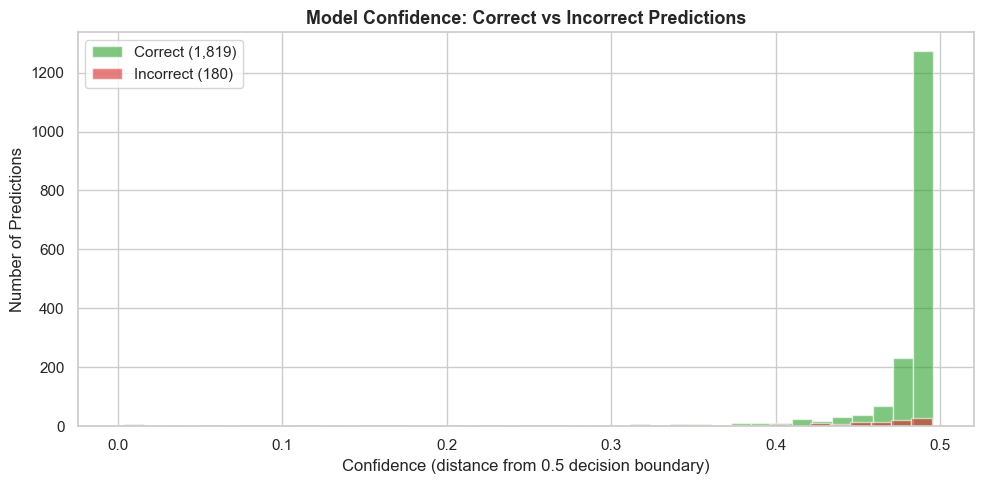

Avg confidence on correct predictions:   0.4701
Avg confidence on incorrect predictions: 0.3526

A well-calibrated model shows higher confidence when correct.


In [23]:
correct_mask = y_pred_bert == y_true_bert
correct_probs = y_prob_bert[correct_mask]
incorrect_probs = y_prob_bert[~correct_mask]

# Convert to distance from 0.5 decision boundary
correct_confidence = np.abs(correct_probs - 0.5)
incorrect_confidence = np.abs(incorrect_probs - 0.5)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(correct_confidence, bins=40, alpha=0.6,
        color='#2ca02c', label=f'Correct ({len(correct_probs):,})', edgecolor='white')
ax.hist(incorrect_confidence, bins=40, alpha=0.6,
        color='#d62728', label=f'Incorrect ({len(incorrect_probs):,})', edgecolor='white')
ax.set_title('Model Confidence: Correct vs Incorrect Predictions',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Confidence (distance from 0.5 decision boundary)')
ax.set_ylabel('Number of Predictions')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg confidence on correct predictions:   {correct_confidence.mean():.4f}')
print(f'Avg confidence on incorrect predictions: {incorrect_confidence.mean():.4f}')
print(f'\nA well-calibrated model shows higher confidence when correct.')

## Production Recommendation

### Which Model Should You Deploy?

The answer depends entirely on the business context. This is the most important thing a data scientist can communicate to a stakeholder.

---

#### Deploy TF-IDF + Logistic Regression when:
- **Real-time inference is required** (under 1ms per prediction)
- **Explainability is a priority** (feature coefficients show exactly why a prediction was made)
- **Infrastructure is constrained** (no GPU, limited memory)
- **The task is high volume** (millions of predictions per day where latency compounds)
- **Regulatory requirements** demand interpretable models (finance, healthcare)

#### Deploy DistilBERT when:
- **Accuracy on the minority class is critical** (missing negative reviews has a high business cost)
- **Reviews contain complex language** (negation, sarcasm, mixed sentiment)
- **Batch processing is acceptable** (overnight scoring of new reviews)
- **GPU infrastructure is available** (reduces inference to under 10ms)
- **The cost of false negatives exceeds infrastructure cost**

---

#### Recommended Production Architecture:

A two-stage system gets the best of both worlds:

1. **Stage 1:** Run all reviews through TF-IDF + LR instantly
2. **Stage 2:** Flag low-confidence predictions (probability between 0.40 and 0.60) and re-score only those with DistilBERT

This way DistilBERT only processes the ambiguous cases, typically 10 to 15% of reviews, keeping latency low while improving accuracy where it matters most.

In [24]:
print('=' * 65)
print('CLASSIFICATION NOTEBOOK SUMMARY')
print('=' * 65)
print(f'\nDataset:')
print(f'  Total reviews available:     {len(df):,}')
print(f'  Training sample:             {len(bert_train_df):,}')
print(f'  Test sample:                 {len(bert_test_df):,}')

print(f'\nBaseline (TF-IDF + Logistic Regression):')
print(f'  Accuracy:                    {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'  F1 Negative (minority):      {f1_score(y_test, y_pred_baseline, pos_label=0):.4f}')
print(f'  F1 Positive (majority):      {f1_score(y_test, y_pred_baseline, pos_label=1):.4f}')
print(f'  ROC-AUC:                     {auc_base:.4f}')
print(f'  Inference per sample:        {inference_time_baseline:.4f} ms')
print(f'  Training time:               {train_time_baseline:.2f} seconds')

print(f'\nAdvanced (DistilBERT Fine-tuned):')
print(f'  Accuracy:                    {accuracy_score(y_true_bert, y_pred_bert):.4f}')
print(f'  F1 Negative (minority):      {f1_score(y_true_bert, y_pred_bert, pos_label=0):.4f}')
print(f'  F1 Positive (majority):      {f1_score(y_true_bert, y_pred_bert, pos_label=1):.4f}')
print(f'  ROC-AUC:                     {auc_bert:.4f}')
print(f'  Inference per sample:        {inference_time_bert:.4f} ms')
print(f'  Training time:               110 minutes (CPU)')

print(f'\nError Analysis:')
print(f'  Baseline wrong, BERT correct: {len(baseline_wrong_bert_right):,}')
print(f'  BERT wrong, Baseline correct: {len(bert_wrong_baseline_right):,}')
print(f'  Both wrong:                   {len(both_wrong):,}')


CLASSIFICATION NOTEBOOK SUMMARY

Dataset:
  Total reviews available:     567,070
  Training sample:             9,999
  Test sample:                 1,999

Baseline (TF-IDF + Logistic Regression):
  Accuracy:                    0.8808
  F1 Negative (minority):      0.7551
  F1 Positive (majority):      0.9213
  ROC-AUC:                     0.9432
  Inference per sample:        0.8067 ms
  Training time:               18.15 seconds

Advanced (DistilBERT Fine-tuned):
  Accuracy:                    0.9100
  F1 Negative (minority):      0.7887
  F1 Positive (majority):      0.9428
  ROC-AUC:                     0.9518
  Inference per sample:        53.6079 ms
  Training time:               110 minutes (CPU)

Error Analysis:
  Baseline wrong, BERT correct: 142
  BERT wrong, Baseline correct: 96
  Both wrong:                   84
